# Exercise 1 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

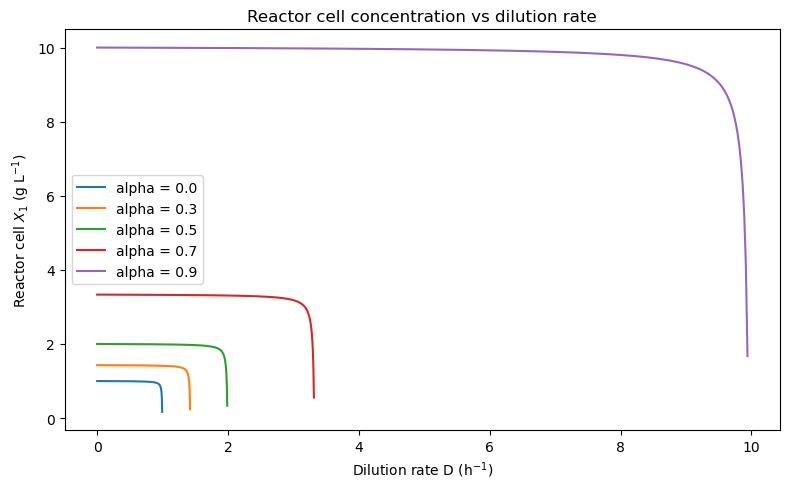

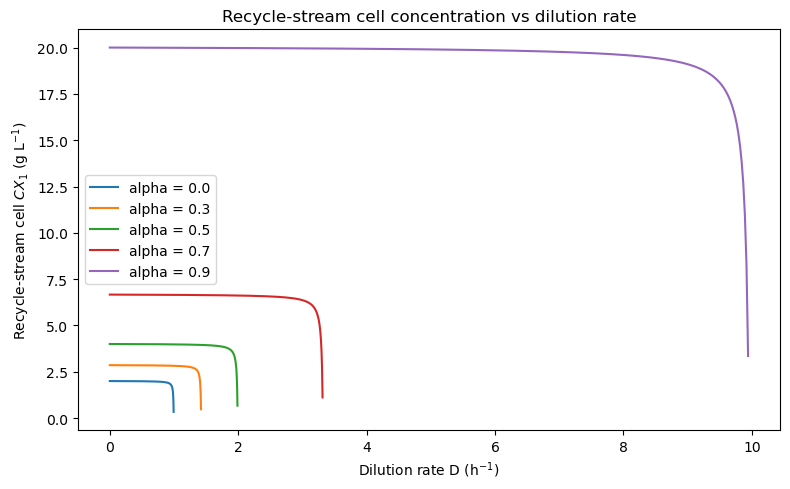

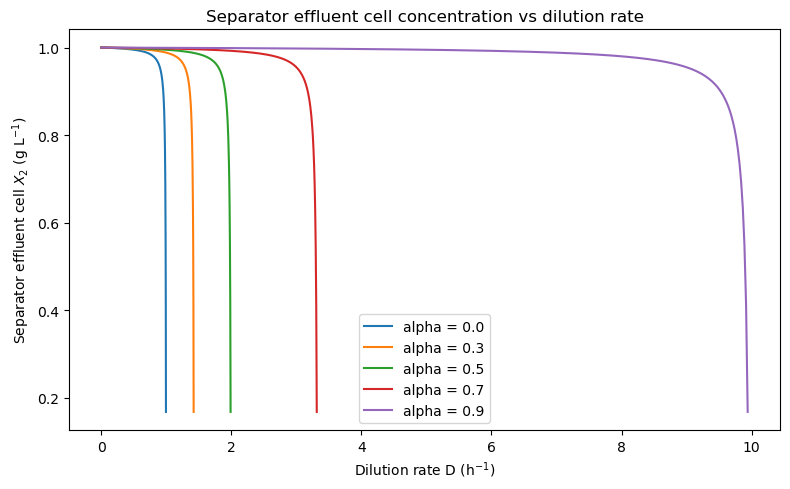

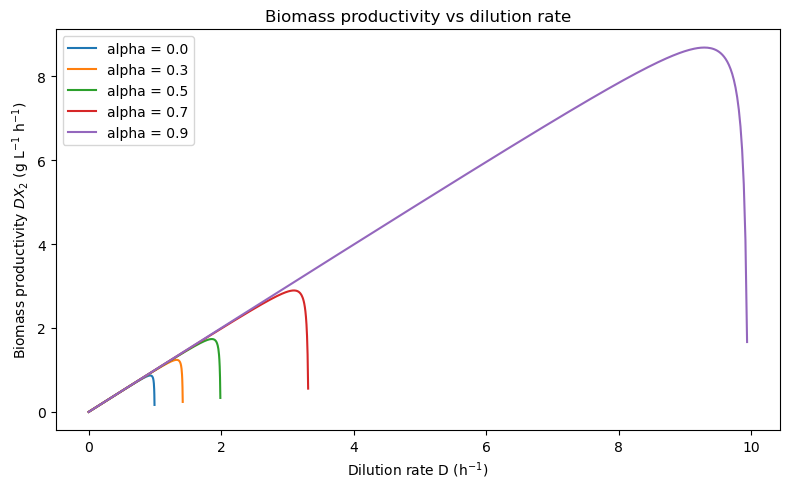


Dmax values:
alpha = 0.0 --> Dmax = 0.9950 h^-1
alpha = 0.3 --> Dmax = 1.4215 h^-1
alpha = 0.5 --> Dmax = 1.9900 h^-1
alpha = 0.7 --> Dmax = 3.3167 h^-1
alpha = 0.9 --> Dmax = 9.9502 h^-1


In [3]:
mu_max = 1.0      
Ks = 0.01         
Yxs = 0.5         
S0 = 2.0        
C = 2.0

alpha_values = [0.0, 0.3, 0.5, 0.7, 0.9]

def delta(alpha):
    return (1 + alpha) - alpha * C

def Dmax(alpha):
    d = delta(alpha)
    return mu_max * S0 / ((Ks + S0) * d)

def substrate_concentration(D, alpha):
    d = delta(alpha)
    return Ks * D * d / (mu_max - D * d)

def reactor_biomass(D, alpha):
    d = delta(alpha)
    S = substrate_concentration(D, alpha)
    return Yxs * (S0 - S) / d

def recycle_biomass(D, alpha):
    return C * reactor_biomass(D, alpha)

def separator_effluent_biomass(D, alpha):
    return delta(alpha) * reactor_biomass(D, alpha)

def biomass_productivity(D, alpha):
    return D * separator_effluent_biomass(D, alpha)

plt.figure(figsize=(8, 5))
for alpha in alpha_values:
    D_vals = np.linspace(1e-4, 0.999 * Dmax(alpha), 400)
    plt.plot(D_vals, reactor_biomass(D_vals, alpha), label=f'alpha = {alpha}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Reactor cell $X_1$ (g L$^{-1}$)')
plt.title('Reactor cell concentration vs dilution rate')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for alpha in alpha_values:
    D_vals = np.linspace(1e-4, 0.999 * Dmax(alpha), 400)
    plt.plot(D_vals, recycle_biomass(D_vals, alpha), label=f'alpha = {alpha}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Recycle-stream cell $C X_1$ (g L$^{-1}$)')
plt.title('Recycle-stream cell concentration vs dilution rate')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for alpha in alpha_values:
    D_vals = np.linspace(1e-4, 0.999 * Dmax(alpha), 400)
    plt.plot(D_vals, separator_effluent_biomass(D_vals, alpha), label=f'alpha = {alpha}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Separator effluent cell $X_2$ (g L$^{-1}$)')
plt.title('Separator effluent cell concentration vs dilution rate')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for alpha in alpha_values:
    D_vals = np.linspace(1e-4, 0.999 * Dmax(alpha), 400)
    plt.plot(D_vals, biomass_productivity(D_vals, alpha), label=f'alpha = {alpha}')
plt.xlabel('Dilution rate D (h$^{-1}$)')
plt.ylabel('Biomass productivity $D X_2$ (g L$^{-1}$ h$^{-1}$)')
plt.title('Biomass productivity vs dilution rate')
plt.legend()
plt.tight_layout()
plt.show()

print('\nDmax values:')
for alpha in alpha_values:
    print(f'alpha = {alpha:.1f} --> Dmax = {Dmax(alpha):.4f} h^-1')


# Exercise 2 - Penicillin 

***Overall kinetics***

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


mu_m = 0.2       
Ks   = 0.5      
Ki   = 50.0   
Yxs  = 0.3      
qp   = 0.08     

F        = 50.0    
Sf       = 100.0  
V0       = 200.0   
Vmax     = 800.0   
Vwithdraw = 600.0  

S_init   = 0.0     
X_init   = 30.0   
P_init   = 0.0     

n_cycles = 10
t_cycle  = (Vmax - V0) / F  


def mu_inhibition(S):
    S = max(S, 0.0)
    return mu_m * S / (Ks + S + S**2 / Ki)

def mu_no_inhibition(S):
    S = max(S, 0.0)
    return mu_m * S / (Ks + S)


def reactor_model(t, y, mu_func, S_feed):
    S, X, P = y
    V = V0 + F * t

    mu = mu_func(S)

    dSdt = (F / V) * (S_feed - S) - (1.0 / Yxs) * mu * X
    dXdt = mu * X - (F / V) * X
    dPdt = qp * X - (F / V) * P

    return [dSdt, dXdt, dPdt]

def simulate_cycles(mu_func, S_feed=Sf, n_cycles=10):
    S0, X0, P0 = S_init, X_init, P_init

    time_total = []
    S_total = []
    X_total = []
    P_total = []

    removed_product_each_cycle_kg = []
    time_shift = 0.0

    for cycle in range(n_cycles):
        sol = solve_ivp(
            lambda t, y: reactor_model(t, y, mu_func, S_feed),
            [0, t_cycle],
            [S0, X0, P0],
            method='RK45',
            t_eval=np.linspace(0, t_cycle, 400),
            max_step=0.05
        )

        t = sol.t + time_shift
        S = sol.y[0]
        X = sol.y[1]
        P = sol.y[2]

        if cycle == 0:
            time_total.extend(t)
            S_total.extend(S)
            X_total.extend(X)
            P_total.extend(P)
        else:
            time_total.extend(t[1:])
            S_total.extend(S[1:])
            X_total.extend(X[1:])
            P_total.extend(P[1:])

        S_end = max(S[-1], 0.0)
        X_end = max(X[-1], 0.0)
        P_end = max(P[-1], 0.0)


        removed_product_each_cycle_kg.append(P_end * Vwithdraw / 1000.0)

        S0, X0, P0 = S_end, X_end, P_end
        time_shift += t_cycle

    return {
        "t": np.array(time_total),
        "S": np.array(S_total),
        "X": np.array(X_total),
        "P": np.array(P_total),
        "removed_product_each_cycle_kg": np.array(removed_product_each_cycle_kg)
    }

***Question b***

In [5]:
print(f"Cycle time = {t_cycle:.2f} h")

Cycle time = 12.00 h


***Question c***

Total product removed after 10 cycles = 136.8731 kg


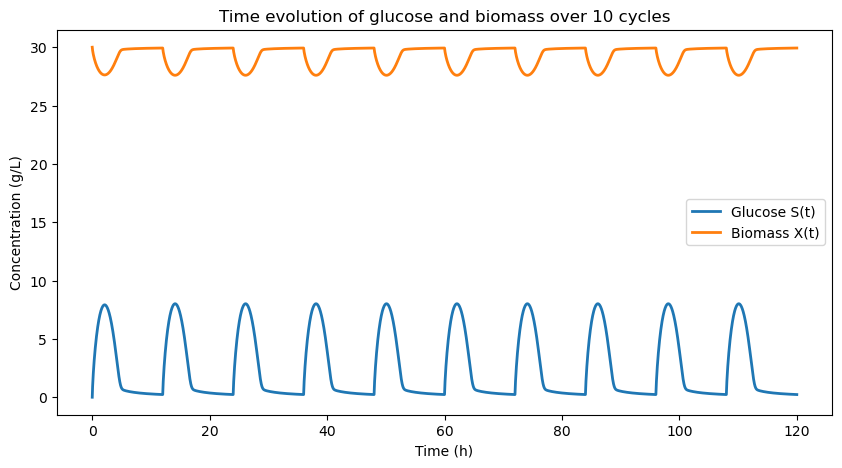

In [6]:
result = simulate_cycles(mu_inhibition, S_feed=Sf, n_cycles=10)

print(f"Total product removed after 10 cycles = {result['removed_product_each_cycle_kg'].sum():.4f} kg")

plt.figure(figsize=(10, 5))
plt.plot(result["t"], result["S"], label="Glucose S(t)", linewidth=2)
plt.plot(result["t"], result["X"], label="Biomass X(t)", linewidth=2)
plt.xlabel("Time (h)")
plt.ylabel("Concentration (g/L)")
plt.title("Time evolution of glucose and biomass over 10 cycles")
plt.grid(False)
plt.legend()
plt.show()

***Question d***

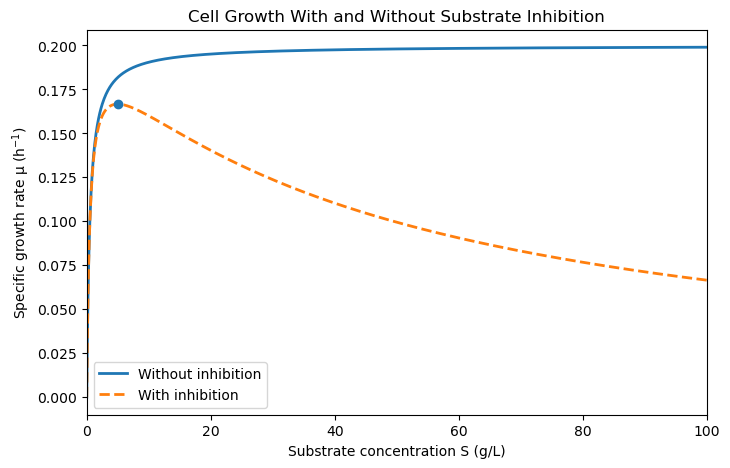

In [7]:
S_range = np.linspace(0, 100, 1000)

mu_monod = np.array([mu_no_inhibition(S) for S in S_range])
mu_inhib = np.array([mu_inhibition(S) for S in S_range])

S_opt = np.sqrt(Ks * Ki)
mu_opt = mu_inhibition(S_opt)

plt.figure(figsize=(8, 5))
plt.plot(S_range, mu_monod, label="Without inhibition", linewidth=2)
plt.plot(S_range, mu_inhib, "--", label="With inhibition", linewidth=2)
plt.scatter(S_opt, mu_opt, zorder=3)


plt.xlabel("Substrate concentration S (g/L)")
plt.ylabel("Specific growth rate μ (h$^{-1}$)")
plt.title("Cell Growth With and Without Substrate Inhibition")
plt.xlim(0, 100)
plt.grid(False)
plt.legend()
plt.show()

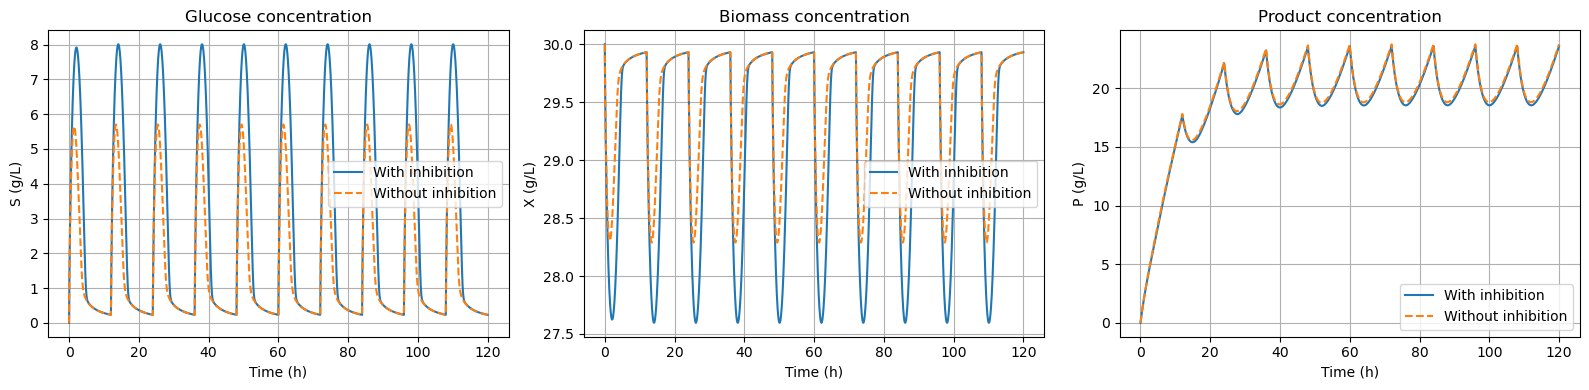

In [8]:
res_inhib = simulate_cycles(mu_inhibition, S_feed=Sf, n_cycles=10)
res_no_inhib = simulate_cycles(mu_no_inhibition, S_feed=Sf, n_cycles=10)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(res_inhib["t"], res_inhib["S"], label="With inhibition")
axes[0].plot(res_no_inhib["t"], res_no_inhib["S"], "--", label="Without inhibition")
axes[0].set_title("Glucose concentration")
axes[0].set_xlabel("Time (h)")
axes[0].set_ylabel("S (g/L)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(res_inhib["t"], res_inhib["X"], label="With inhibition")
axes[1].plot(res_no_inhib["t"], res_no_inhib["X"], "--", label="Without inhibition")
axes[1].set_title("Biomass concentration")
axes[1].set_xlabel("Time (h)")
axes[1].set_ylabel("X (g/L)")
axes[1].grid(True)
axes[1].legend()

axes[2].plot(res_inhib["t"], res_inhib["P"], label="With inhibition")
axes[2].plot(res_no_inhib["t"], res_no_inhib["P"], "--", label="Without inhibition")
axes[2].set_title("Product concentration")
axes[2].set_xlabel("Time (h)")
axes[2].set_ylabel("P (g/L)")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

***Question f***

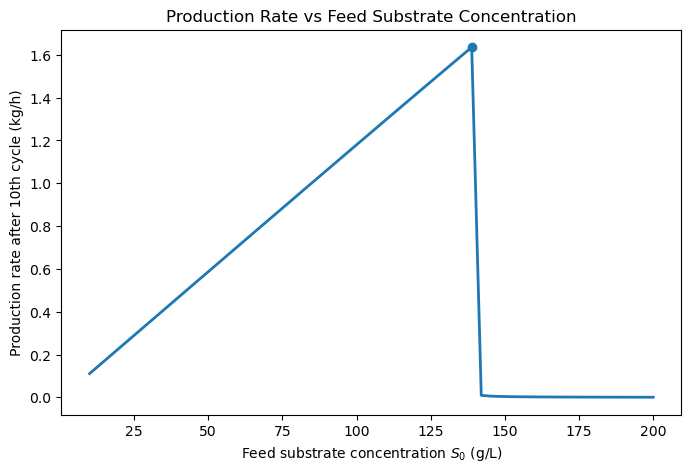

Optimal feed substrate concentration = 138.81 g/L
Maximum production rate = 1.6356 kg/h


In [9]:
S_feed_values = np.linspace(10, 200, 60)
production_rates_kg_h = []

for S_feed in S_feed_values:
    result = simulate_cycles(mu_inhibition, S_feed=S_feed, n_cycles=10)

    mP_10th_cycle = result["removed_product_each_cycle_kg"][-1]   
    rate = mP_10th_cycle / t_cycle                                
    production_rates_kg_h.append(rate)

production_rates_kg_h = np.array(production_rates_kg_h)

idx_opt = np.argmax(production_rates_kg_h)
S_feed_opt = S_feed_values[idx_opt]
rate_opt = production_rates_kg_h[idx_opt]

plt.figure(figsize=(8, 5))
plt.plot(S_feed_values, production_rates_kg_h, linewidth=2)
plt.scatter(S_feed_opt, rate_opt, zorder=3)


plt.xlabel("Feed substrate concentration $S_0$ (g/L)")
plt.ylabel("Production rate after 10th cycle (kg/h)")
plt.title("Production Rate vs Feed Substrate Concentration")
plt.grid(False)
plt.show()

print(f"Optimal feed substrate concentration = {S_feed_opt:.2f} g/L")
print(f"Maximum production rate = {rate_opt:.4f} kg/h")

# Exercise 3

***Question a***

In [2]:
import numpy as np
from scipy.optimize import fsolve

F = 100       # L/h
S0 = 10       # g/L
Yxs = 0.5    # g/g
mu_m = 1.0   # h⁻¹
Ks = 0.75    # g/L

def monod(S):
    return mu_m * S / (Ks + S)

V1, V2 = 800, 200
D1 = F / V1 
D2 = F / V2  

print(f"Reactor 1")
print(f"D1 = {D1:.4f} h⁻¹")

# Reactor 1
if D1 >= mu_m:
    print("WASHOUT : D1 >= mu_max")
    print("X1 = 0 g/L")
    print(f"S1 = {S0} g/L (no consumption)")
    X1 = 0
    S1 = S0
else:
    mu1 = D1
    S1 = mu1 * Ks / (mu_m - mu1)
    X1 = Yxs * (S0 - S1)
    print(f"mu1 = {mu1:.4f} h⁻¹")
    print(f"S1 = {S1:.4f} g/L")
    print(f"X1 = {X1:.4f} g/L")

# Reactor 2
def equations_R2(vars):
    S2, X2 = vars
    mu2 = monod(S2)
    eq1 = D2 * (X1 - X2) + mu2 * X2
    eq2 = D2 * (S1 - S2) - (mu2 * X2) / Yxs
    return [eq1, eq2]

S2_init, X2_init = 0.5, 3.0
S2, X2 = fsolve(equations_R2, [S2_init, X2_init])
mu2 = monod(S2)

print(f"\nReactor 2")
print(f"D2 = {D2:.4f} h⁻¹")
print(f"mu2 = {mu2:.4f} h⁻¹")
print(f"S2 = {S2:.4f} g/L")
print(f"X2 = {X2:.4f} g/L")

Reactor 1
D1 = 0.1250 h⁻¹
mu1 = 0.1250 h⁻¹
S1 = 0.1071 g/L
X1 = 4.9464 g/L

Reactor 2
D2 = 0.5000 h⁻¹
mu2 = 0.0052 h⁻¹
S2 = 0.0039 g/L
X2 = 4.9981 g/L


***Question b***

In [3]:
import numpy as np
from scipy.optimize import fsolve

F = 100       # L/h
S0 = 10       # g/L
Yxs = 0.5    # g/g
mu_m = 1.0   # h⁻¹
Ks = 0.75    # g/L

def monod(S):
    return mu_m * S / (Ks + S)

V1, V2 = 200, 800
D1 = F / V1 
D2 = F / V2  

print(f"Reactor 1")
print(f"D1 = {D1:.4f} h⁻¹")

# Reactor 1
if D1 >= mu_m:
    print("WASHOUT : D1 >= mu_max")
    print("X1 = 0 g/L")
    print(f"S1 = {S0} g/L (no consumption)")
    X1 = 0
    S1 = S0
else:
    mu1 = D1
    S1 = mu1 * Ks / (mu_m - mu1)
    X1 = Yxs * (S0 - S1)
    print(f"mu1 = {mu1:.4f} h⁻¹")
    print(f"S1 = {S1:.4f} g/L")
    print(f"X1 = {X1:.4f} g/L")

# Reactor 2
def equations_R2(vars):
    S2, X2 = vars
    mu2 = monod(S2)
    eq1 = D2 * (X1 - X2) + mu2 * X2
    eq2 = D2 * (S1 - S2) - (mu2 * X2) / Yxs
    return [eq1, eq2]

S2_init, X2_init = 0.5, 3.0
S2, X2 = fsolve(equations_R2, [S2_init, X2_init])
mu2 = monod(S2)

print(f"\nReactor 2")
print(f"D2 = {D2:.4f} h⁻¹")
print(f"mu2 = {mu2:.4f} h⁻¹")
print(f"S2 = {S2:.4f} g/L")
print(f"X2 = {X2:.4f} g/L")

Reactor 1
D1 = 0.5000 h⁻¹
mu1 = 0.5000 h⁻¹
S1 = 0.7500 g/L
X1 = 4.6250 g/L

Reactor 2
D2 = 0.1250 h⁻¹
mu2 = 0.0093 h⁻¹
S2 = 0.0070 g/L
X2 = 4.9965 g/L


***Question c***

In [4]:
import numpy as np
from scipy.optimize import fsolve

F = 100       # L/h
S0 = 10       # g/L
Yxs = 0.5    # g/g
mu_m = 1.0   # h⁻¹
Ks = 0.75    # g/L

def monod(S):
    return mu_m * S / (Ks + S)

V1, V2 = 900, 100
D1 = F / V1 
D2 = F / V2  

print(f"Reactor 1")
print(f"D1 = {D1:.4f} h⁻¹")

# Reactor 1
if D1 >= mu_m:
    print("WASHOUT : D1 >= mu_max")
    print("X1 = 0 g/L")
    print(f"S1 = {S0} g/L (no consumption)")
    X1 = 0
    S1 = S0
else:
    mu1 = D1
    S1 = mu1 * Ks / (mu_m - mu1)
    X1 = Yxs * (S0 - S1)
    print(f"mu1 = {mu1:.4f} h⁻¹")
    print(f"S1 = {S1:.4f} g/L")
    print(f"X1 = {X1:.4f} g/L")

# Reactor 2
def equations_R2(vars):
    S2, X2 = vars
    mu2 = monod(S2)
    eq1 = D2 * (X1 - X2) + mu2 * X2
    eq2 = D2 * (S1 - S2) - (mu2 * X2) / Yxs
    return [eq1, eq2]

S2_init, X2_init = 0.5, 3.0
S2, X2 = fsolve(equations_R2, [S2_init, X2_init])
mu2 = monod(S2)

print(f"\nReactor 2")
print(f"D2 = {D2:.4f} h⁻¹")
print(f"mu2 = {mu2:.4f} h⁻¹")
print(f"S2 = {S2:.4f} g/L")
print(f"X2 = {X2:.4f} g/L")

Reactor 1
D1 = 0.1111 h⁻¹
mu1 = 0.1111 h⁻¹
S1 = 0.0938 g/L
X1 = 4.9531 g/L

Reactor 2
D2 = 1.0000 h⁻¹
mu2 = 0.0087 h⁻¹
S2 = 0.0066 g/L
X2 = 4.9967 g/L


***Question d***

In [1]:
import numpy as np
from scipy.optimize import fsolve

F = 100       # L/h
S0 = 10       # g/L
Yxs = 0.5    # g/g
mu_m = 1.0   # h⁻¹
Ks = 0.75    # g/L

def monod(S):
    return mu_m * S / (Ks + S)

V1, V2 = 100, 900
D1 = F / V1 
D2 = F / V2  

print(f"Reactor 1")
print(f"D1 = {D1:.4f} h⁻¹")

# Reactor 1
if D1 >= mu_m:
    print("WASHOUT : D1 >= mu_max")
    print("X1 = 0 g/L")
    print(f"S1 = {S0} g/L (no consumption)")
    X1 = 0
    S1 = S0
else:
    mu1 = D1
    S1 = mu1 * Ks / (mu_m - mu1)
    X1 = Yxs * (S0 - S1)
    print(f"mu1 = {mu1:.4f} h⁻¹")
    print(f"S1 = {S1:.4f} g/L")
    print(f"X1 = {X1:.4f} g/L")

# Reactor 2
def equations_R2(vars):
    S2, X2 = vars
    mu2 = monod(S2)
    eq1 = D2 * (X1 - X2) + mu2 * X2
    eq2 = D2 * (S1 - S2) - (mu2 * X2) / Yxs
    return [eq1, eq2]

S2_init, X2_init = 0.5, 3.0
S2, X2 = fsolve(equations_R2, [S2_init, X2_init])
mu2 = monod(S2)

print(f"\nReactor 2")
print(f"D2 = {D2:.4f} h⁻¹")
print(f"mu2 = {mu2:.4f} h⁻¹")
print(f"S2 = {S2:.4f} g/L")
print(f"X2 = {X2:.4f} g/L")

Reactor 1
D1 = 1.0000 h⁻¹
WASHOUT : D1 >= mu_max
X1 = 0 g/L
S1 = 10 g/L (no consumption)

Reactor 2
D2 = 0.1111 h⁻¹
mu2 = 0.1111 h⁻¹
S2 = 0.0937 g/L
X2 = 4.9531 g/L


# Bonus

In [10]:
mu_m  = 0.7    
Ks    = 0.02  
Yxs   = 0.5    
alpha = 0.1    
beta  = 0.02   
S0    = 1.0    

In [11]:
def steady_state(D):
    if D >= mu_m:
        return 0.0, 0.0, 0.0
    S = Ks * D / (mu_m - D)
    if S >= S0:
        return 0.0, 0.0, 0.0
    X = Yxs * (S0 - S)
    P = (alpha + beta / D) * X
    return S, X, P

In [12]:
D_vals = np.linspace(1e-4, mu_m - 1e-4, 5000)

PD_vals = np.array([steady_state(D)[2] * D for D in D_vals])
XD_vals = np.array([steady_state(D)[1] * D for D in D_vals])

D_opt_P = D_vals[np.argmax(PD_vals)]
D_opt_X = D_vals[np.argmax(XD_vals)]

print(f"Optimal D for product productivity  (PD): D = {D_opt_P:.4f} h^-1")
print(f"Optimal D for biomass productivity  (XD): D = {D_opt_X:.4f} h^-1")

Optimal D for product productivity  (PD): D = 0.5889 h^-1
Optimal D for biomass productivity  (XD): D = 0.6020 h^-1


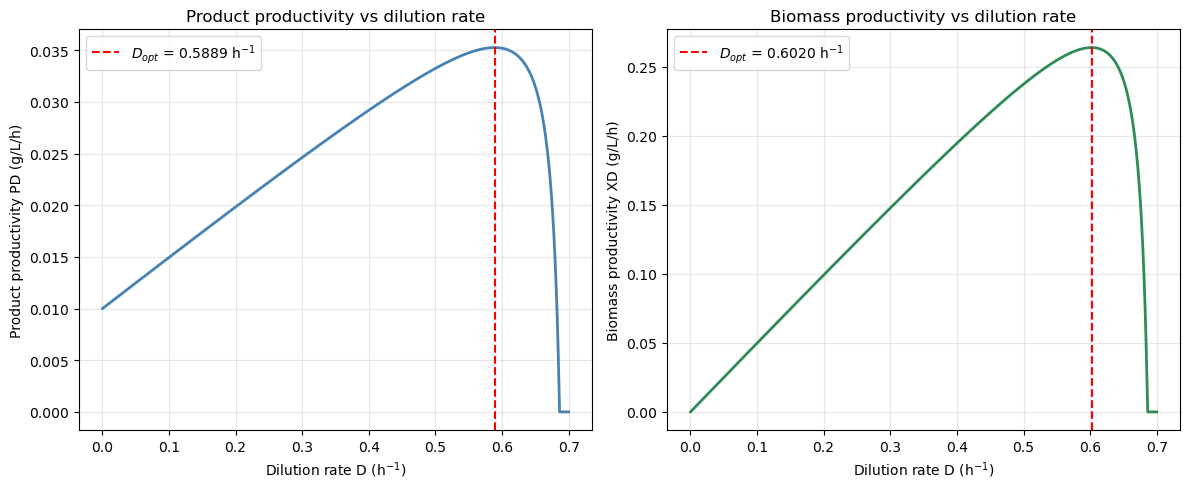

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(D_vals, PD_vals, color='steelblue', linewidth=2)
axes[0].axvline(D_opt_P, color='red', linestyle='--', label=f'$D_{{opt}}$ = {D_opt_P:.4f} h$^{{-1}}$')
axes[0].set_xlabel('Dilution rate D (h$^{-1}$)')
axes[0].set_ylabel('Product productivity PD (g/L/h)')
axes[0].set_title('Product productivity vs dilution rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


axes[1].plot(D_vals, XD_vals, color='seagreen', linewidth=2)
axes[1].axvline(D_opt_X, color='red', linestyle='--', label=f'$D_{{opt}}$ = {D_opt_X:.4f} h$^{{-1}}$')
axes[1].set_xlabel('Dilution rate D (h$^{-1}$)')
axes[1].set_ylabel('Biomass productivity XD (g/L/h)')
axes[1].set_title('Biomass productivity vs dilution rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()